In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [38]:
df = pd.read_csv("./Online_Retail.csv",encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [42]:
df = df.drop(columns=['StockCode','Description', 'Country','InvoiceDate','CustomerI'], errors='ignore')
df

,InvoiceNo,Quantity,UnitPrice,CustomerID
0,536365,6,2.55,17850.0
1,536365,6,3.39,17850.0
2,536365,8,2.75,17850.0
3,536365,6,3.39,17850.0
4,536365,6,3.39,17850.0
...,...,...,...,...
541904,581587,12,0.85,12680.0
541905,581587,6,2.10,12680.0
541906,581587,4,4.15,12680.0
541907,581587,4,4.15,12680.0


In [44]:
X = df[['InvoiceNo','Quantity','UnitPrice']]
y = df ['CustomerID']

In [51]:
X= X.drop(columns=['InvoiceNo'], errors='ignore')

In [52]:
X.corr()

,Quantity,UnitPrice
Quantity,1.000000,-0.001235
UnitPrice,-0.001235,1.000000


Text(0, 0.5, 'WCSS')

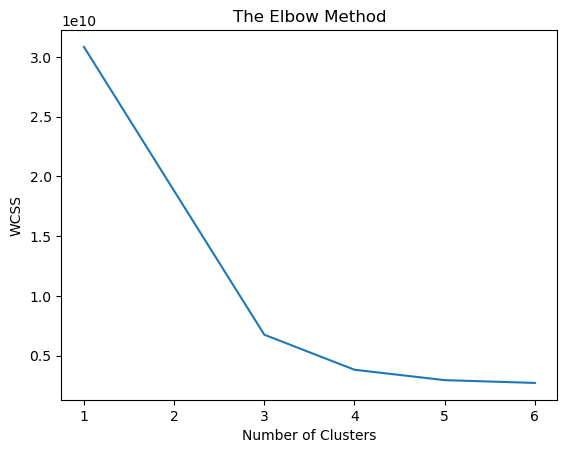

In [53]:
wcss = []

for i in range(1, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

number_clusters = range(1, 7)

plt.plot(number_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
